# Module 9 — Visualisation

Produces all publication-quality figures for your project report:

| Figure | Content |
|---|---|
| `results.png` | 6-panel: 3 images + 3 histograms |
| `fuzzy_output_mf.png` | Aggregated fuzzy MF + centroid |
| `params_radar.png` | Radar chart of CNN-predicted parameters |
| `histogram_overlay.png` | Before/after histogram overlay |


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from config        import Config
from enhancer      import ImageEnhancer
from evaluator     import evaluate_enhancement
from fuzzy_system  import FuzzyEnhancementSystem, adjustment_mf_vec

import os

print("Imports successful.")

Imports successful.


In [4]:
#Load images

if os.path.exists(Config.SAMPLE_IMAGE):
    original = cv2.imread(Config.SAMPLE_IMAGE)
    original = cv2.resize(original, Config.IMAGE_SIZE)
else:
    np.random.seed(7)
    base     = np.random.randint(20, 90, (*Config.IMAGE_SIZE, 3), dtype=np.uint8)
    original = cv2.GaussianBlur(base, (9, 9), 0)

enhancer         = ImageEnhancer()
cnn_fuzzy_img, info  = enhancer.enhance(original)
fuzzy_only_img, _    = enhancer.enhance_fuzzy_only(original)
metrics          = evaluate_enhancement(original, fuzzy_only_img, cnn_fuzzy_img)

print("All images generated.")

[Enhancer] CNN loaded from 'cnn_enhancer.pth'
[Enhancer] Fuzzy system initialised.
IMAGE ENHANCEMENT EVALUATION Method │  PSNR (dB) │ SSIMFuzzy only  24.263 | 0.73505CNN + Fuzzy  14.064 | 0.37393Best PSNR: Fuzzy onlyBest SSIM: Fuzzy only
All images generated.


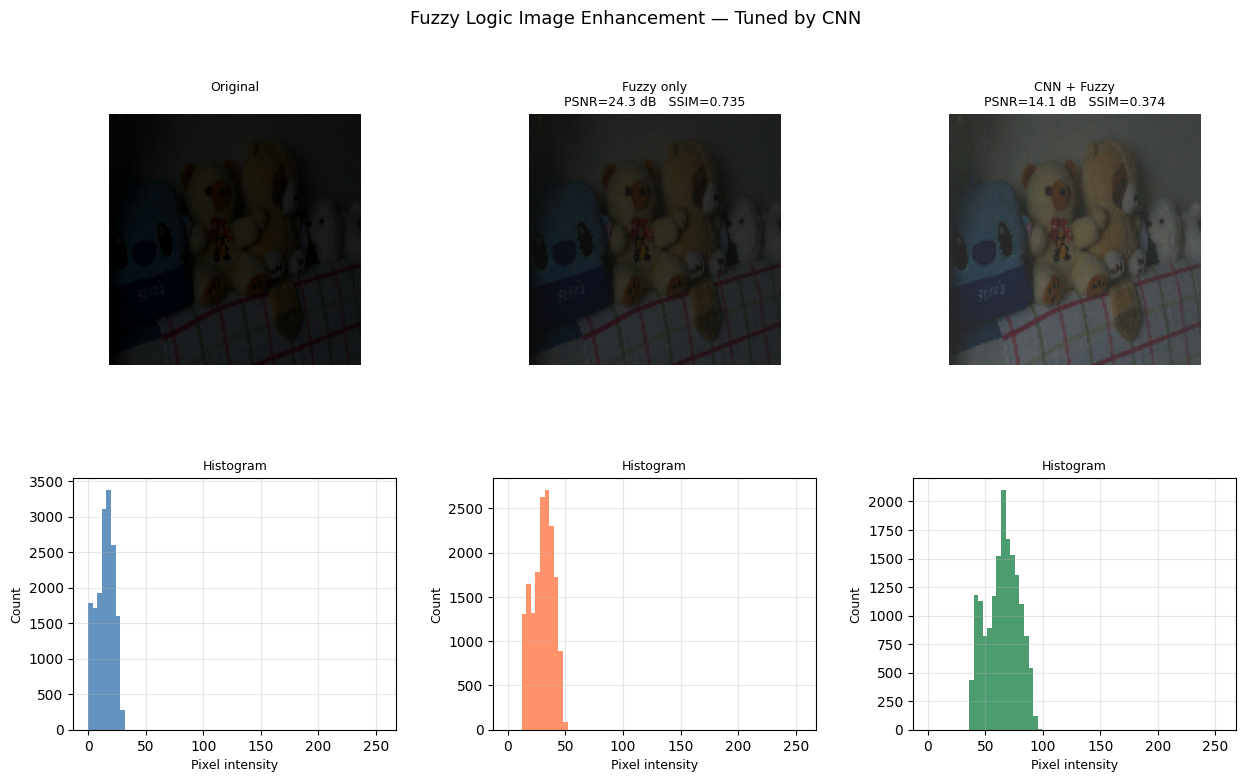

✅ Saved results.png


In [5]:
#Figure 1: 6-panel results (images + histograms)

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

images       = [original,         fuzzy_only_img,     cnn_fuzzy_img]
titles       = ["Original",       "Fuzzy only",       "CNN + Fuzzy"]
hist_colors  = ["steelblue",      "coral",            "seagreen"]
metric_lbls  = [
    "",
    f"PSNR={metrics['psnr_fuzzy']:.1f} dB   SSIM={metrics['ssim_fuzzy']:.3f}",
    f"PSNR={metrics['psnr_cnn']:.1f} dB   SSIM={metrics['ssim_cnn']:.3f}",
]

for col, (img, title, color, mlbl) in enumerate(
        zip(images, titles, hist_colors, metric_lbls)):

    # Row 0: image
    ax_img = fig.add_subplot(gs[0, col])
    disp   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    ax_img.imshow(disp, cmap="gray" if img.ndim == 2 else None)
    ax_img.set_title(f"{title}\n{mlbl}", fontsize=9)
    ax_img.axis("off")

    # Row 1: histogram
    ax_hist = fig.add_subplot(gs[1, col])
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    ax_hist.hist(gray.ravel(), bins=64, range=(0, 255),
                 color=color, alpha=0.85, edgecolor="none")
    ax_hist.set_xlabel("Pixel intensity", fontsize=9)
    ax_hist.set_ylabel("Count",           fontsize=9)
    ax_hist.set_title("Histogram",        fontsize=9)
    ax_hist.grid(alpha=0.3)

fig.suptitle("Fuzzy Logic Image Enhancement — Tuned by CNN", fontsize=13, y=1.01)
plt.savefig("results.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved results.png")

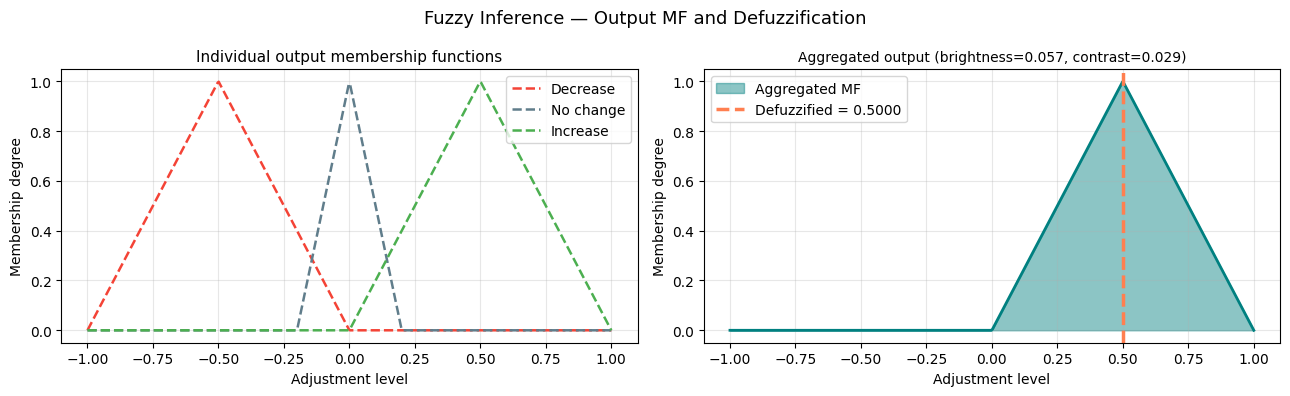

Saved fuzzy_output_mf.png


In [7]:
#Figure 2: Fuzzy output MF + centroid

fis    = FuzzyEnhancementSystem()
x_out  = fis.get_universe()
result = fis.infer(info["features"]["mean"], info["features"]["std"])
agg    = result["aggregated"]
crisp  = result["adjustment"]

# Individual output MFs (dashed, for reference)
dec = adjustment_mf_vec(x_out, "decrease")
nc  = adjustment_mf_vec(x_out, "no_change")
inc = adjustment_mf_vec(x_out, "increase")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for vals, lbl, col in [(dec, "Decrease", "#F44336"),
                        (nc,  "No change", "#607D8B"),
                        (inc, "Increase",  "#4CAF50")]:
    ax1.plot(x_out, vals, "--", color=col, label=lbl, linewidth=1.8)
ax1.set_title("Individual output membership functions", fontsize=11)
ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_xlabel("Adjustment level")
ax1.set_ylabel("Membership degree")

ax2.fill_between(x_out, agg, alpha=0.45, color="teal", label="Aggregated MF")
ax2.plot(x_out, agg, color="teal", linewidth=2)
ax2.axvline(crisp, color="coral", linewidth=2.5, linestyle="--",
            label=f"Defuzzified = {crisp:.4f}")
ax2.set_title(f"Aggregated output (brightness={info['features']['mean']:.3f}, "
              f"contrast={info['features']['std']:.3f})", fontsize=10)
ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_xlabel("Adjustment level")
ax2.set_ylabel("Membership degree")

plt.suptitle("Fuzzy Inference — Output MF and Defuzzification", fontsize=13)
plt.tight_layout()
plt.savefig("fuzzy_output_mf.png", dpi=120)
plt.show()
print("Saved fuzzy_output_mf.png")

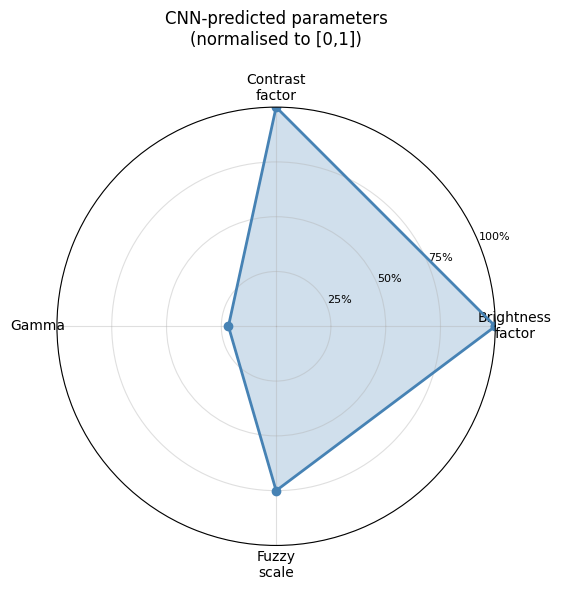

 Saved params_radar.png


In [9]:
#Figure 3: Radar / spider chart of CNN-predicted parameters 

import matplotlib

categories = ["Brightness\nfactor", "Contrast\nfactor", "Gamma", "Fuzzy\nscale"]

# Normalise all to [0, 1] for display
def norm01(v, lo, hi):
    return (v - lo) / (hi - lo + 1e-8)

values = [
    norm01(info["brightness_factor"], *Config.BRIGHTNESS_RANGE),
    norm01(info["contrast_factor"],   *Config.CONTRAST_RANGE),
    norm01(info["gamma"],             *Config.GAMMA_RANGE),
    norm01(info["fuzzy_scale"],        0.5,  1.5),
]
values += [values[0]]  # close the polygon

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, "o-", linewidth=2, color="steelblue")
ax.fill(angles, values, alpha=0.25, color="steelblue")
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8)
ax.set_title("CNN-predicted parameters\n(normalised to [0,1])", fontsize=12, pad=20)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("params_radar.png", dpi=120)
plt.show()
print(" Saved params_radar.png")

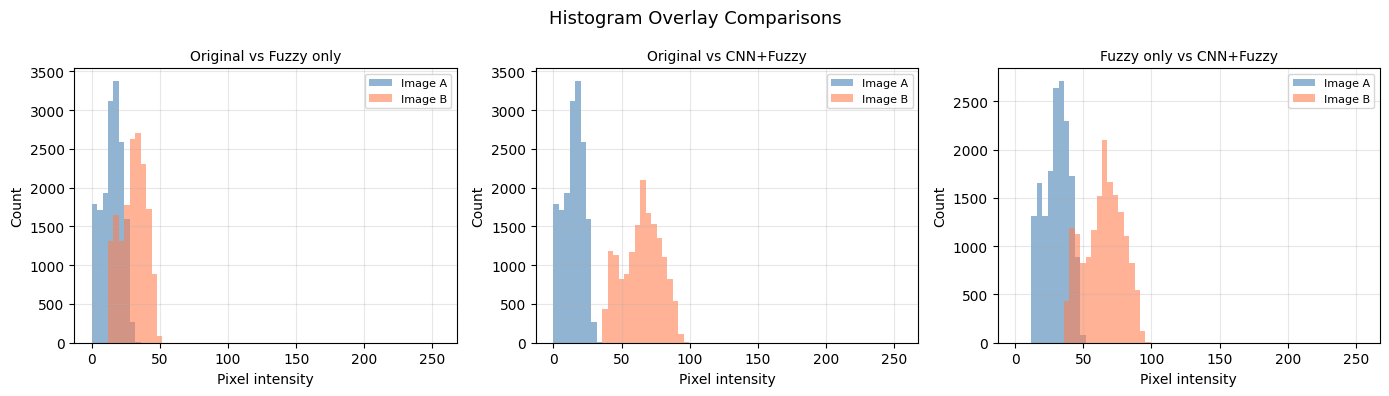

Saved histogram_overlay.png


In [11]:
#figure 4: Histogram overlay (before vs after)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ("Original vs Fuzzy only",   original, fuzzy_only_img),
    ("Original vs CNN+Fuzzy",    original, cnn_fuzzy_img),
    ("Fuzzy only vs CNN+Fuzzy",  fuzzy_only_img, cnn_fuzzy_img),
]

for ax, (title, img_a, img_b) in zip(axes, pairs):
    gray_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2GRAY) if img_a.ndim == 3 else img_a
    gray_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2GRAY) if img_b.ndim == 3 else img_b

    ax.hist(gray_a.ravel(), bins=64, range=(0, 255),
            alpha=0.6, color="steelblue", label="Image A", edgecolor="none")
    ax.hist(gray_b.ravel(), bins=64, range=(0, 255),
            alpha=0.6, color="coral",    label="Image B", edgecolor="none")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Histogram Overlay Comparisons", fontsize=13)
plt.tight_layout()
plt.savefig("histogram_overlay.png", dpi=120)
plt.show()
print("Saved histogram_overlay.png")

In [15]:
#Print parameter summary table

print("\n── Predicted Enhancement Parameters ──")
print(f"  Mean intensity (brightness) : {info['features']['mean']:.4f}")
print(f"  Std deviation  (contrast)   : {info['features']['std']:.4f}")
print(f"  Shannon entropy             : {info['features']['entropy']:.4f}")
print(f"  Dark pixel ratio            : {info['features']['dark_ratio']:.4f}")
print()
print(f"  CNN brightness factor       : {info['brightness_factor']:.4f}")
print(f"  CNN contrast factor         : {info['contrast_factor']:.4f}")
print(f"  CNN gamma                   : {info['gamma']:.4f}")
print(f"  Fuzzy adjustment            : {info['fuzzy_adjustment']:.4f}")
print(f"  Fuzzy scale                 : {info['fuzzy_scale']:.4f}")
print()
print(f"── Active fuzzy rules ({len(info['active_rules'])}) ──")
for r in info["active_rules"]:
    bar = "█" * int(r["strength"] * 20)
    print(f"  {r['rule']:<40s} [{bar:<20s}] {r['strength']:.3f}")


── Predicted Enhancement Parameters ──
  Mean intensity (brightness) : 0.0566
  Std deviation  (contrast)   : 0.0288
  Shannon entropy             : 3.3140
  Dark pixel ratio            : 1.0000

  CNN brightness factor       : 2.0000
  CNN contrast factor         : 2.0000
  CNN gamma                   : 0.8569
  Fuzzy adjustment            : 0.5000
  Fuzzy scale                 : 1.2500

── Active fuzzy rules (1) ──
  IF dark AND low -> increase              [████████████████████] 1.000


In [17]:
#Save visualizer module to disk

viz_code = '''
import cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fuzzy_system import FuzzyEnhancementSystem, adjustment_mf_vec
from config import Config

def show_enhancement_results(original, fuzzy, cnn_fuzzy, info, metrics,
                              save_path="results.png"):
    fig = plt.figure(figsize=(15, 8))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
    images      = [original, fuzzy, cnn_fuzzy]
    titles      = ["Original", "Fuzzy only", "CNN + Fuzzy"]
    hist_colors = ["steelblue", "coral", "seagreen"]
    metric_lbls = ["",
        f"PSNR={metrics[\"psnr_fuzzy\"]:.1f} dB  SSIM={metrics[\"ssim_fuzzy\"]:.3f}",
        f"PSNR={metrics[\"psnr_cnn\"]:.1f} dB  SSIM={metrics[\"ssim_cnn\"]:.3f}"]
    for col, (img, title, color, mlbl) in enumerate(zip(images, titles, hist_colors, metric_lbls)):
        ax_img = fig.add_subplot(gs[0, col])
        disp   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        ax_img.imshow(disp, cmap="gray" if img.ndim == 2 else None)
        ax_img.set_title(f"{title}\\n{mlbl}", fontsize=9)
        ax_img.axis("off")
        ax_hist = fig.add_subplot(gs[1, col])
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
        ax_hist.hist(gray.ravel(), bins=64, range=(0,255), color=color, alpha=0.85, edgecolor="none")
        ax_hist.set_xlabel("Pixel intensity", fontsize=9)
        ax_hist.set_ylabel("Count", fontsize=9)
        ax_hist.set_title("Histogram", fontsize=9)
    fig.suptitle("Fuzzy Logic Image Enhancement — Tuned by CNN", fontsize=13, y=1.01)
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
'''

with open("visualizer.py", "w") as f:
    f.write(viz_code)

print(" visualizer.py written to disk.")

 visualizer.py written to disk.
